In [19]:
import os

import matplotlib.pyplot
import matplotlib.pyplot as plt
import numpy
import numpy as np
import pandas
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import umap
from matplotlib.colors import LogNorm
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (adjusted_rand_score, completeness_score,
                             homogeneity_score, normalized_mutual_info_score,
                             silhouette_score)

from transformers import AutoModel, AutoTokenizer
from torch.utils.data import DataLoader, TensorDataset

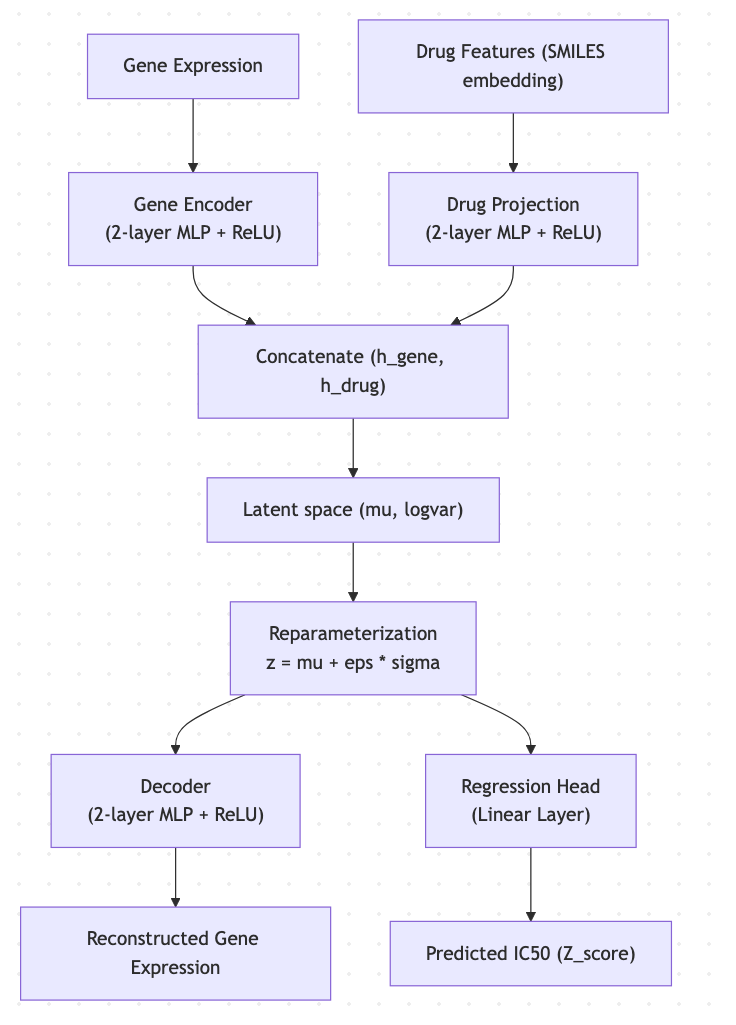

In [4]:
cellline = pd.read_csv(
    "../dataset/gdsc/cellline_info.csv.gz",
    usecols=["COSMIC_ID", "SMILES", "NAME", "Z_score"],
)
exp = pd.read_csv("../dataset/gdsc/exp.csv.gz", index_col=0)
# exp = exp.reset_index()
# exp = exp.rename(columns={'index': 'COSMIC_ID'})

In [5]:
cellline.head()

,COSMIC_ID,NAME,SMILES,Z_score
0,684057,Erlotinib,COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C...,1.305495
1,684059,Erlotinib,COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C...,0.166286
2,684062,Erlotinib,COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C...,-0.025053
3,684072,Erlotinib,COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C...,-0.422233
4,687448,Erlotinib,COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C...,0.411083


In [6]:
exp.head()

,A1BG,A1CF,A2M,A2ML1,A4GALT,AADAC,AADAT,AAMDC,AARD,AASS,...,ZNRF1,ZNRF3,ZP3,ZSCAN16,ZSCAN18,ZSCAN31,ZSWIM5,ZSWIM6,ZWINT,ZYX
1240121,0.339974,-0.134210,-0.355801,0.153685,1.440833,-0.331754,-0.704305,-1.691068,-0.330709,0.657685,...,-0.223181,-0.752625,1.194265,-0.335577,-0.726587,0.425547,-0.298837,0.674141,-0.894967,0.061661
1240122,-0.206343,-0.321519,-0.454970,6.562916,-0.230353,-0.363170,0.278443,-1.810932,-0.200803,-0.914611,...,-0.049129,-0.750682,1.064771,-0.827131,-0.391908,-0.330118,-0.647183,0.204954,0.197851,-0.598001
1240123,-0.796043,3.275579,-0.233277,-0.166684,-1.415383,-0.174504,-1.157096,-0.187764,-0.221570,-0.803604,...,0.033635,1.301943,0.491792,0.575152,-1.171501,0.321854,3.571441,-0.564238,1.392452,-0.323448
1240125,0.575801,-0.198913,0.348788,-0.358565,-0.683234,-0.274522,-0.553155,-0.175391,0.080745,0.666923,...,-1.270085,0.400413,-0.054072,-1.507854,-1.213952,-1.236961,0.073607,0.203281,-0.675965,0.313539
1240127,0.793076,-0.393730,-0.501831,-0.178046,0.884821,-0.472541,0.182855,0.370835,-0.328202,0.161762,...,-0.203885,1.487751,0.676292,1.019452,0.682361,-0.437988,0.477985,-0.869309,0.783501,0.781815


In [7]:
cellline.shape

(284826, 4)

In [8]:
exp.shape

(942, 6255)

In [11]:
# 学習済みモデルの指定（ChemBERTa）
MODEL_NAME = "seyonec/ChemBERTa-zinc-base-v1"

# トークナイザーとモデルをロード
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)

# GPUが使える場合はGPUに
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

RobertaModel(
  (embeddings): RobertaEmbeddings(
    (word_embeddings): Embedding(767, 768, padding_idx=1)
    (position_embeddings): Embedding(514, 768, padding_idx=1)
    (token_type_embeddings): Embedding(1, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): RobertaEncoder(
    (layer): ModuleList(
      (0-5): 6 x RobertaLayer(
        (attention): RobertaAttention(
          (self): RobertaSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): RobertaSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
            (dropou

In [12]:
# SMILESサンプル
smiles_list = cellline["SMILES"].unique().tolist()

# トークナイズ
inputs = tokenizer(smiles_list, padding=True, truncation=True, return_tensors="pt")
inputs = {k: v.to(device) for k, v in inputs.items()}

# モデルからEmbeddingを取得（[CLS]トークンのベクトルを使用）
with torch.no_grad():
    outputs = model(**inputs)
    embeddings = outputs.last_hidden_state[:, 0, :]  # [batch_size, hidden_size]

In [13]:
drugs = pd.DataFrame(embeddings)
drugs.index = smiles_list
drugs

,0,1,2,3,4,5,6,7,8,9,...,758,759,760,761,762,763,764,765,766,767
COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C)OCCOC.Cl,-1.050597,0.707250,-0.964086,1.113762,0.485391,-0.737595,-0.627737,-0.259253,-0.330486,-1.499637,...,0.761067,0.658469,1.158078,-0.320328,0.415883,0.817152,-1.770794,-1.167749,-0.207771,0.313511
CC1CCC2CC(C(=CC=CC=CC(CC(C(=O)C(C(C(=CC(C(=O)CC(OC(=O)C3CCCCN3C(=O)C(=O)C1(O2)O)C(C)CC4CCC(C(C4)OC)O)C)C)O)OC)C)C)C)OC,0.742618,0.892284,-0.898234,-1.281915,-0.303817,-1.636318,0.148198,0.020804,-0.542048,-0.417950,...,0.832454,-0.690302,1.160766,-1.564932,0.032995,0.726153,-1.652401,-0.653466,-0.125991,1.181779
CC1CCC2CC(C(=CC=CC=CC(CC(C(=O)C(C(C(=CC(C(=O)CC(OC(=O)C3CCCCN3C(=O)C(=O)C1(O2)O)C(C)CC4CCC(C(C4)OC)O)C)C)OC(=O)CN(C)C)OC)C)C)C)OC.CS(=O)(=O)O,0.582011,0.794053,-0.991772,-1.119777,-0.352806,-1.600424,0.019393,0.037857,-0.701407,-0.369376,...,0.894068,-0.633111,1.181516,-1.668517,0.279995,0.597589,-1.477463,-0.777517,-0.020838,1.079303
CCN(CC)CCNC(=O)C1=C(NC(=C1C)C=C2C3=C(C=CC(=C3)F)NC2=O)C,0.497329,-0.578951,-0.338625,0.066813,0.119136,-0.982863,0.069714,0.293693,-1.449713,-0.378519,...,1.278994,-1.077578,0.940059,-0.421631,0.482418,0.069901,-0.548726,-1.732865,-0.035673,1.326400
CC1=C(NC(=C1C(=O)N2CCCC2CN3CCCC3)C)C=C4C5=C(C=CC(=C5)S(=O)(=O)CC6=C(C=CC=C6Cl)Cl)NC4=O,-1.096772,0.532320,-1.807294,0.314229,-0.549873,-1.258943,-1.189271,0.011935,-0.829287,-1.530034,...,0.213487,0.036804,0.879213,-1.374781,0.628368,0.675248,-1.786189,-0.470424,0.377478,0.393163
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CC(C)OC1=NNC(=C1)NC2=NC(=NC=C2Cl)NC(C)C3=NC=C(C=C3)F,-0.089175,-0.170955,-1.038749,0.159720,0.774729,-0.459262,-0.466690,-0.119063,-1.736788,-0.394134,...,1.492343,-0.261071,0.870562,-0.421771,0.973910,0.069015,-1.080953,-1.673161,-0.575387,0.735953
CCC1=C2CN3C(=CC4=C(C3=O)COC(=O)C4(CC)O)C2=NC5=C1C=C(C=C5)O,-0.004251,0.597173,0.130440,0.143033,1.043154,-0.310820,-0.738294,-0.770809,-0.291298,-0.545712,...,0.835681,-1.381773,0.097001,-0.731483,-0.282368,2.745789,-0.455199,-0.182686,-0.041304,1.703436
C1CC2=CC=CC=C2C1NC3=C4C=CN(C4=NC=N3)C5CC(C(C5)O)COS(=O)(=O)N,0.293201,0.014222,-0.571382,-0.136923,-0.178418,-0.026191,-0.736505,-0.334918,-0.810331,-0.359814,...,1.346193,-0.321884,-0.066355,-0.644960,0.539093,0.810056,-0.504175,-0.763789,-0.090358,1.787473
C1[C@@H]2CN([C@H]1CN2C3=CC=CC=N3)/C=C/C(=O)C4=CC=CC=C4O,1.192879,0.493158,0.221977,-1.268351,-0.552493,-1.012531,-0.486602,0.169851,-1.111012,-0.024830,...,0.560108,-0.079611,1.867081,-0.223862,0.733111,-0.623100,-1.022324,-0.649369,0.396534,0.113935


In [14]:
exp.index = exp.index.astype(str)
cellline["COSMIC_ID"] = cellline["COSMIC_ID"].astype(str)
drugs.index = drugs.index.astype(str)

In [15]:
exp_values = exp.to_numpy(dtype=np.float32)  # shape=(n_cells, n_genes)
cid_to_row = {cid: i for i, cid in enumerate(exp.index)}  # COSMIC_ID -> row idx

# 薬：ベクトルを辞書化（SMILES -> np.float32[768]）
drug_vec = {s: drugs.loc[s].to_numpy(dtype=np.float32) for s in drugs.index}

# cellline 側で存在しないID/SMILESを落とす（安全のため）
mask = cellline["COSMIC_ID"].isin(exp.index) & cellline["SMILES"].isin(drugs.index)
cellline_small = cellline.loc[mask].reset_index(drop=True)
print(f"usable pairs: {len(cellline_small):,} / {len(cellline):,}")

usable pairs: 284,826 / 284,826


In [16]:
from VAE_GDSC import GeneDrugVAE, GDSCDataset

In [20]:
from torch.utils.data import random_split

batch_size = 4096 * 2
ds = GDSCDataset(cellline_small, exp_values, cid_to_row, drug_vec)
# dl = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=False, num_workers=0)

# train/val split (8:2)
val_ratio = 0.2
n_total = len(ds)
n_val = int(n_total * val_ratio)
n_train = n_total - n_val

train_ds, val_ds = random_split(ds, [n_train, n_val])
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False)
val_dl   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, drop_last=False)

In [21]:

gene_dim = exp_values.shape[1]
smiles_dim = 768
lr = 1.5e-4

device = (
    torch.device("cuda")
    if torch.cuda.is_available()
    else (
        torch.device("mps")
        if torch.backends.mps.is_available()
        else torch.device("cpu")
    )
)
device_type = (
    "cuda" if device.type == "cuda" else ("mps" if device.type == "mps" else "cpu")
)
use_amp = device_type in ("cuda", "mps")

# GradScaler は CUDA のみ
scaler = torch.amp.GradScaler(enabled=(device_type == "cuda"))

model = GeneDrugVAE(
    gene_dim, drug_dim=smiles_dim, proj_dim=256, hidden=512, latent=128
).to(device)
opt = torch.optim.Adam(model.parameters(), lr=lr)

num_epochs = 60
C_max, C_steps, gamma = 10.0, 30, 10.0
lam = 0.5
beta_elbo = 1.0  # 後半（ELBO段）でのKL重み。0.5〜2.0で要アブレーション

In [23]:
from tqdm import tqdm

In [24]:
os.makedirs("models/gdsc", exist_ok=True)  # 保存ディレクトリを作成

best_val = float("inf")
best_path = "models/gdsc/gdsc_best.pt"

for ep in range(num_epochs):
    model.train()
    C = C_max * (ep / C_steps) if ep < C_steps else C_max
    
    m_total = n = 0
    for xg, xd, y in tqdm(train_dl, desc=f"Train E{ep+1}", leave=False):
        xg, xd, y = xg.to(device), xd.to(device), y.to(device)
        opt.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=device_type, enabled=use_amp):
            recon, mu, lv, yhat = model(xg, xd)
            rec = F.mse_loss(recon, xg, reduction="mean")
            kl = 0.5 * (-1 - lv + mu.pow(2) + lv.exp()).sum(dim=1).mean()
            zloss = F.mse_loss(yhat, y, reduction="mean")
            capgap = torch.abs(kl - C)
            loss = rec + gamma * capgap + lam * zloss
        if device_type == "cuda":
            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            scaler.step(opt)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
        m_total += loss.item(); n += 1
    train_loss = m_total / n

    # ---- validation ----
    model.eval()
    val_loss = 0; n_val_batches = 0
    with torch.no_grad():
        for xg, xd, y in val_dl:
            xg, xd, y = xg.to(device), xd.to(device), y.to(device)
            recon, mu, lv, yhat = model(xg, xd)
            rec = F.mse_loss(recon, xg, reduction="mean")
            kl = 0.5 * (-1 - lv + mu.pow(2) + lv.exp()).sum(dim=1).mean()
            zloss = F.mse_loss(yhat, y, reduction="mean")
            capgap = torch.abs(kl - C)
            loss = rec + gamma * capgap + lam * zloss
            val_loss += loss.item(); n_val_batches += 1
    val_loss /= n_val_batches

    print(f"Epoch {ep+1}/{num_epochs} | Train {train_loss:.4f} | Val {val_loss:.4f}")

    # ---- save best ----
    if val_loss < best_val - 1e-6:
        best_val = val_loss
        torch.save(model.state_dict(), best_path)
        print(f"[Save] Best model updated at epoch {ep+1}: {best_path}")


Epoch 1/60 | Train 1.9511 | Val 1.6930
[Save] Best model updated at epoch 1: models/gdsc/gdsc_best.pt


Epoch 2/60 | Train 3.9901 | Val 2.2784


Epoch 3/60 | Train 3.2188 | Val 1.7717


Epoch 4/60 | Train 3.3976 | Val 3.4000


Epoch 5/60 | Train 3.0503 | Val 1.8118


...

Epoch 56/60 | Train 3.1013 | Val 3.4502


Epoch 57/60 | Train 3.1365 | Val 3.6828


Epoch 58/60 | Train 3.2524 | Val 3.8703


Epoch 59/60 | Train 3.6789 | Val 7.4266


Epoch 60/60 | Train 5.0886 | Val 3.1457


# How to eval from loading the model

In [16]:
# # 1. Build the model and load the trained weights
# model = GeneDrugVAE(gene_dim, drug_dim=768, proj_dim=256, hidden=512, latent=128).to(device)
# model.load_state_dict(torch.load("models/gdsc/gdsc_last.pt", map_location=device))
# model.eval()  # set to evaluation mode

# # 2. Extract latent representations (μ) for all samples
# mus = []
# with torch.no_grad():  # disable gradient computation
#     for xg, xd, _ in dl:   # ignore y (IC50), only need xg and xd
#         xg = xg.to(device, non_blocking=True)
#         xd = xd.to(device, non_blocking=True)
#         mu, lv = model.encode(xg, xd)   # encode gene + drug into latent space
#         mus.append(mu.cpu().numpy())    # collect μ on CPU

# # Concatenate all latent vectors into one array
# Z_mu = np.concatenate(mus, axis=0)
# print("Latent shape:", Z_mu.shape)

In [17]:
# ---------- 1) 全サンプルの μ をバッチで抽出 ----------
model.eval()
mus = []
with torch.no_grad():
    # 推論用 DataLoader（shuffle=False）
    infer_dl = DataLoader(ds, batch_size=8192, shuffle=False, num_workers=0)
    for xg, xd, y in tqdm(infer_dl, desc="Encode (μ)", leave=False):
        xg = xg.to(device, non_blocking=True)
        xd = xd.to(device, non_blocking=True)
        mu, logvar = model.encode(xg, xd)  # GeneDrugVAE で encode を実装している前提
        mus.append(mu.cpu().numpy())

Z_mu = np.concatenate(mus, axis=0)  # (N, latent)

In [18]:
# 可視化用メタ：薬ラベル & Z_score（元の ds に対応する順序を確保）
# cellline_small の順序が ds と一致している前提（Dataset 内でそのまま index を使っている実装ならOK）
meta_df = cellline_small.reset_index(drop=True).copy()
# NAME が無い場合は SMILES を代用
drug_label = meta_df["NAME"] if "NAME" in meta_df.columns else meta_df["SMILES"]
zscore = meta_df["Z_score"].values
cellline = meta_df["COSMIC_ID"]

In [21]:
X0 = StandardScaler(with_mean=True, with_std=True).fit_transform(Z_mu)
X = (
    PCA(n_components=min(100, X0.shape[1]), random_state=42)
    .fit_transform(X0)
    .astype("float32")
)

umap2d = umap.UMAP(
    n_neighbors=40,
    min_dist=0.05,
    metric="cosine",
    init="spectral",
    densmap=True,
    random_state=42,
    low_memory=True,
    verbose=True,
).fit_transform(X)

/Users/inouey2/miniconda3/envs/torch/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


UMAP(angular_rp_forest=True, densmap=True, metric='cosine', min_dist=0.05, n_jobs=1, n_neighbors=40, random_state=42, verbose=True)
Sun Sep 14 00:34:28 2025 Construct fuzzy simplicial set
Sun Sep 14 00:34:28 2025 Finding Nearest Neighbors
Sun Sep 14 00:34:28 2025 Building RP forest with 32 trees
Sun Sep 14 00:34:33 2025 NN descent for 18 iterations
	 1  /  18
	 2  /  18
	Stopping threshold met -- exiting after 2 iterations
Sun Sep 14 00:35:16 2025 Finished Nearest Neighbor Search
Sun Sep 14 00:35:28 2025 Construct embedding
Sun Sep 14 00:36:33 2025 Computing original densities


Epochs completed:   0%|            0/400 [00:00]

	completed  0  /  400 epochs
	completed  40  /  400 epochs
	completed  80  /  400 epochs
	completed  120  /  400 epochs
	completed  160  /  400 epochs
	completed  200  /  400 epochs
	completed  240  /  400 epochs
	completed  280  /  400 epochs
	completed  320  /  400 epochs
	completed  360  /  400 epochs
Sun Sep 14 00:43:47 2025 Finished embedding


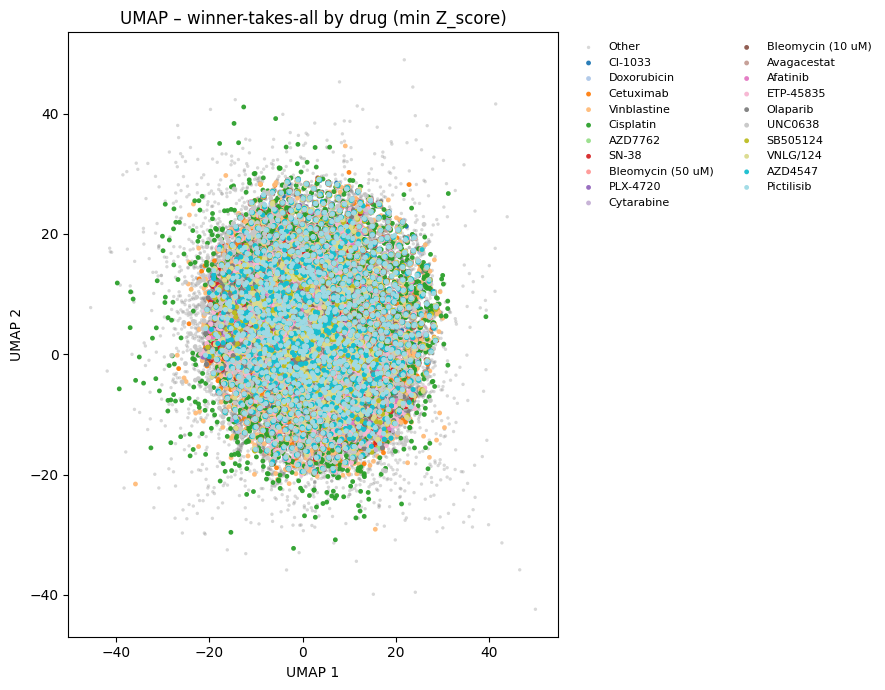

In [22]:
# 入力: umap2d (N,2), drug_label (N,), zscore (N,)
labs = pd.Series(drug_label).astype(str).str.strip().values
z = np.asarray(zscore, dtype=float)

# 座標で集約（丸めて同一点判定）
xy = np.round(umap2d, 6)
df = pd.DataFrame({"x": xy[:, 0], "y": xy[:, 1], "drug": labs, "z": z})

# 各座標で「z が最小の薬」を代表に採用（効きが強い薬）
idx = df.groupby(["x", "y"])["z"].idxmin()
rep = df.loc[idx].reset_index(drop=True)  # x,y,drug,z が 1行/座標

# 可視化（Top-20 + Other）
vc = rep["drug"].value_counts()
top_k = 20
top = list(vc.head(top_k).index)

cmap = plt.colormaps.get_cmap("tab20")
colors = {d: cmap(i / (top_k - 1)) for i, d in enumerate(top)}
other_color = (0.5, 0.5, 0.5, 0.25)

plt.figure(figsize=(9, 7))
# Otherを下地に
m_other = ~rep["drug"].isin(top)
plt.scatter(
    rep.loc[m_other, "x"],
    rep.loc[m_other, "y"],
    s=6,
    alpha=0.30,
    color=other_color,
    rasterized=True,
    zorder=1,
    label="Other",
    edgecolors="none",
)
# Top-20 を重ねる
for d in top:
    m = rep["drug"].values == d
    if m.any():
        plt.scatter(
            rep.loc[m, "x"],
            rep.loc[m, "y"],
            s=12,
            alpha=0.95,
            color=colors[d],
            label=d,
            rasterized=True,
            zorder=3,
            edgecolors="none",
        )

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP – winner-takes-all by drug (min Z_score)")
plt.legend(
    bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, frameon=False, ncol=2
)
plt.tight_layout()
plt.show()

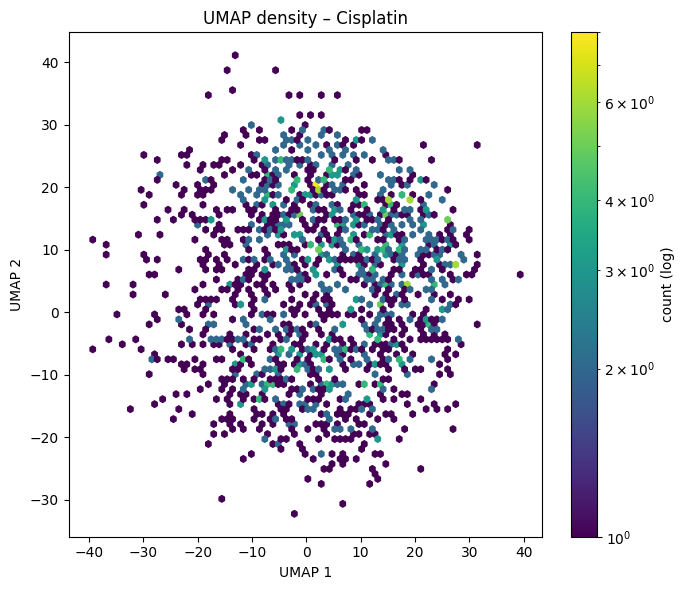

In [23]:
labs = pd.Series(drug_label).astype(str).str.strip().values
drug = "Cisplatin"  # 例

m = labs == drug
plt.figure(figsize=(7, 6))
plt.hexbin(umap2d[m, 0], umap2d[m, 1], gridsize=80, mincnt=1, norm=LogNorm())
cb = plt.colorbar()
cb.set_label("count (log)")
plt.title(f"UMAP density – {drug}")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.tight_layout()
plt.show()